# Entrenamiento de una Convnet para clasificación de imágenes (Cats and Dogs)

## Cargamos y exploramos los datos
Utilizamos un dataset a partir del que se utilizó en una competición en Kaggle en 2013 (el original contenía 25.000 imágenes), con 2000 imágenes de perros y gatos. Lo extraemos al directorio temporal.

In [1]:
# Ejecutamos lo siguiente para descargar el dataset.
# Podremos encontrar los archivos en el directorio correspondiente
# en la pestaña de Archivos en el menú de la izquierda.

!wget --no-check-certificate \
    https://storage.googleapis.com/mledu-datasets/cats_and_dogs_filtered.zip \
    -O /tmp/cats_and_dogs_filtered.zip

# !unzip /tmp/cats_and_dogs_filtered.zip

--2025-03-16 12:15:52--  https://storage.googleapis.com/mledu-datasets/cats_and_dogs_filtered.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 142.250.101.207, 142.250.141.207, 142.251.2.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.250.101.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 68606236 (65M) [application/zip]
Saving to: ‘/tmp/cats_and_dogs_filtered.zip’

/tmp/cats_and_dogs_ 100%[===================>]  65.43M   120MB/s    in 0.5s    

2025-03-16 12:15:53 (120 MB/s) - ‘/tmp/cats_and_dogs_filtered.zip’ saved [68606236/68606236]



In [2]:
import os
import zipfile

local_zip = '/tmp/cats_and_dogs_filtered.zip'
zip_ref = zipfile.ZipFile(local_zip, 'r')
zip_ref.extractall('/tmp')
zip_ref.close()

### ImageDataGenerator
En el caso de las convnets, es necesario un preprocesado especial de los datos, algo diferente al de las redes neuronales convencionales, pues se trabaja con tensores y no con vectores planos. En keras, la forma más cómoda de preparar los datos es a través del módulo ImageDataGenerator. Aquí puedes ver cómo lo aplicamos a nuestras imágenes de perros y gatos.

In [3]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(rescale=1./255)
valid_datagen = ImageDataGenerator(rescale =1./255)

train_dir = '/tmp/cats_and_dogs_filtered/train'
valid_dir = '/tmp/cats_and_dogs_filtered/validation'

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size= (150,150),
    batch_size=20,
    class_mode='binary')

valid_gen = valid_datagen.flow_from_directory(
    valid_dir,
    target_size=(150,150),
    batch_size=20,
    class_mode='binary')

Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


In [4]:
# Los índices serán los siguientes
# Para las imágenes de gatos (0) y
# para las imágenes de perros (1)
train_gen.class_indices

{'cats': 0, 'dogs': 1}

0.0


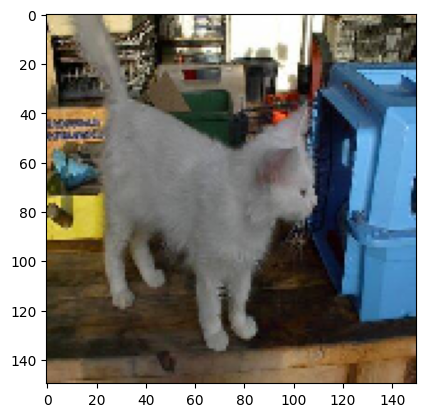

In [5]:
# Visualizamos las imágenes que se generan
import matplotlib.pyplot as plt

batchX, batchY = next(train_gen)

plt.imshow(batchX[0])
print(batchY[0])

In [6]:
batchX.shape

(20, 150, 150, 3)

## Construimos y entrenamos el modelo

In [7]:
from tensorflow.keras import layers
from tensorflow.keras import models

model = models.Sequential()

model.add(layers.Conv2D(32,  (3,3), activation="relu"))
model.add(layers.MaxPooling2D(2,2))
model.add(layers.Conv2D(64,  (3,3), activation="relu"))
model.add(layers.MaxPooling2D(2,2))
model.add(layers.Conv2D(128, (3,3), activation="relu"))
model.add(layers.MaxPooling2D(2,2))
model.add(layers.Conv2D(128, (3,3), activation="relu"))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Flatten())

model.add(layers.Dense(512, activation="relu"))
model.add(layers.Dense(1, activation="sigmoid"))

In [8]:
from tensorflow.keras import optimizers

opt = optimizers.RMSprop(learning_rate=0.0001)

model.compile(loss='binary_crossentropy',
              optimizer=opt,
              metrics=['acc'])


In [9]:
hist = model.fit(train_gen, validation_data=valid_gen, epochs=30)



Epoch 1/30


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


100/100 ━━━━━━━━━━━━━━━━━━━━ 11s 55ms/step - acc: 0.5015 - loss: 0.6977 - val_acc: 0.5000 - val_loss: 0.6955
Epoch 2/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - acc: 0.5555 - loss: 0.6839 - val_acc: 0.6220 - val_loss: 0.6612
Epoch 3/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - acc: 0.6024 - loss: 0.6686 - val_acc: 0.6260 - val_loss: 0.6442
Epoch 4/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - acc: 0.6159 - loss: 0.6502 - val_acc: 0.6550 - val_loss: 0.6230
Epoch 5/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - acc: 0.6597 - loss: 0.6151 - val_acc: 0.6800 - val_loss: 0.6006
Epoch 6/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - acc: 0.6854 - loss: 0.5850 - val_acc: 0.6850 - val_loss: 0.5898
Epoch 7/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - acc: 0.7089 - loss: 0.5632 - val_acc: 0.6910 - val_loss: 0.5822
Epoch 8/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - acc: 0.7301 - loss: 0.5389 - val_acc: 0.6890 - val_loss: 0.5800
Epoch 9/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - acc

## Evaluamos el modelo

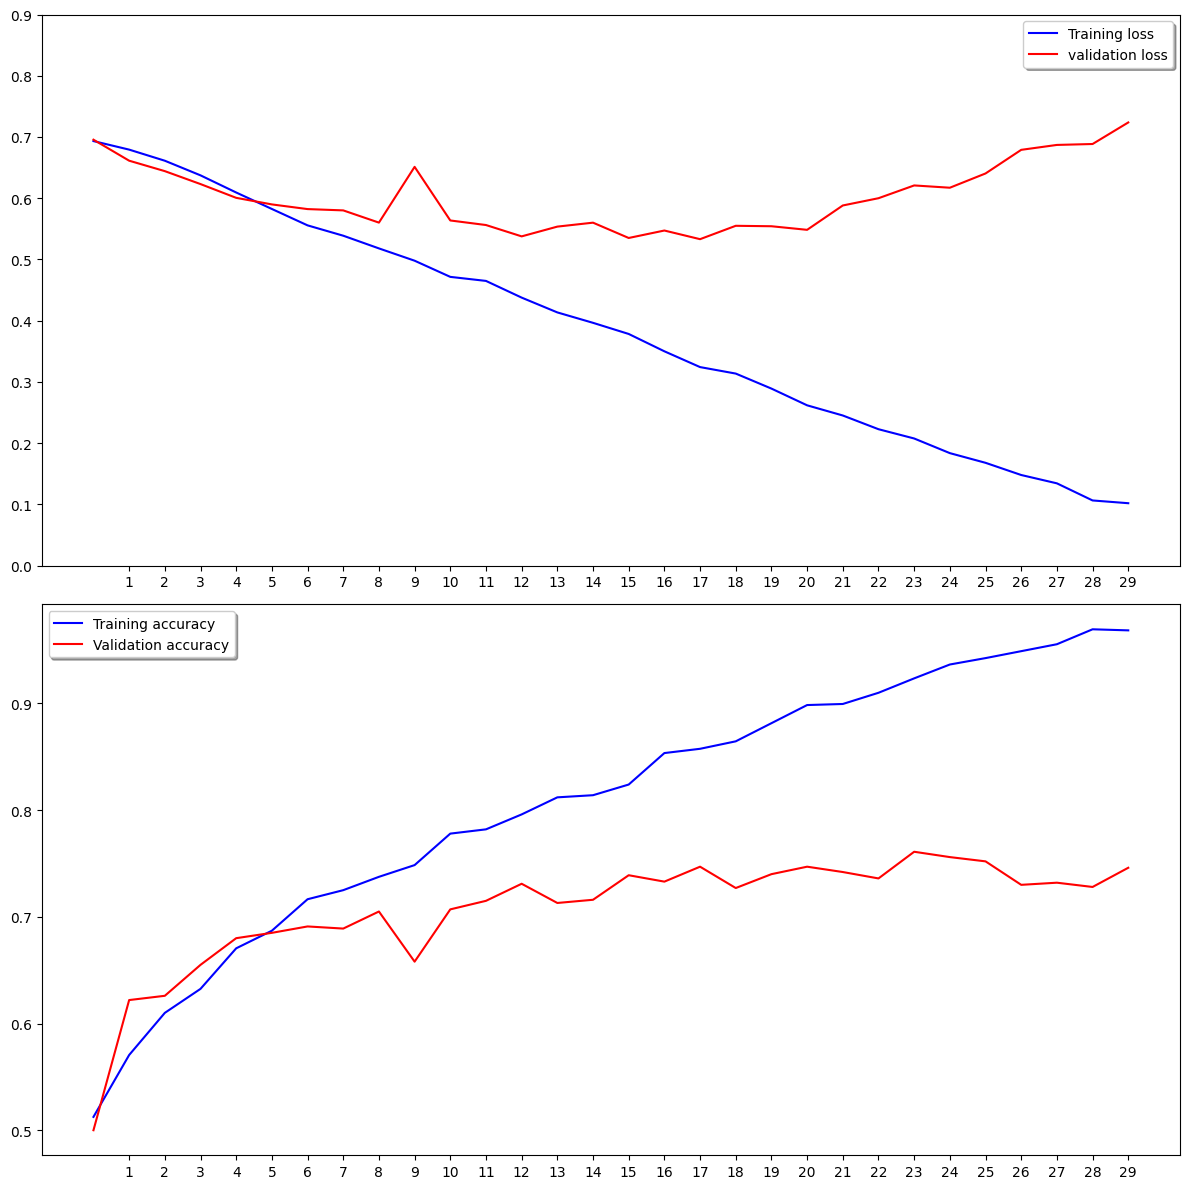

In [10]:
import numpy as np

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12))
ax1.plot(hist.history['loss'], color='b', label="Training loss")
ax1.plot(hist.history['val_loss'], color='r', label="validation loss")
ax1.set_xticks(np.arange(1, 30, 1))
ax1.set_yticks(np.arange(0, 1, 0.1))
ax1.legend(loc='best', shadow=True)

ax2.plot(hist.history['acc'], color='b', label="Training accuracy")
ax2.plot(hist.history['val_acc'], color='r',label="Validation accuracy")
ax2.set_xticks(np.arange(1, 30, 1))
ax2.legend(loc='best', shadow=True)
plt.tight_layout()
plt.show()

# Técnica de Dataset aumentado

Ya hemos visto que el overfitting puede ser evitado si contamos con un conjunto de datos lo mayor posible. Si modificamos las imágenes de forma que sigan siendo representativas, pero que para el modelo sean nuevas, le ayudaremos a generalizar mejor.

## Trucos para aumentar el dataset



*   Rotación entre 0 y 180 grados.
*   Cambios de altura o anchura
*   Recortes
*   Aumentos
*   Simetrías

Tras las transformaciones, también es útil la funcionalidad de añadir pixeles de relleno en las zonas que quedan vacías.



In [11]:
train_datagen = ImageDataGenerator(
rescale=1./255,
rotation_range=40,
width_shift_range=0.2,
height_shift_range=0.2,
shear_range=0.2,
zoom_range=0.2,
horizontal_flip=True,)

valid_datagen = ImageDataGenerator(rescale =1./255)

train_dir = '/tmp/cats_and_dogs_filtered/train'
valid_dir = '/tmp/cats_and_dogs_filtered/validation'

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size= (150,150),
    batch_size=32,
    class_mode='binary')

valid_gen = valid_datagen.flow_from_directory(
    valid_dir,
    target_size=(150,150),
    batch_size=32,
    class_mode='binary')


Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


## Nuevo modelo con dropout
Definimos ahora una nueva red neuronal convolucional, añadiendo dropout tras el bloque convolucional

In [13]:
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu',
input_shape=(150, 150, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Flatten())
model.add(layers.Dropout(0.5))
model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

opt = optimizers.RMSprop(learning_rate=0.0001)

model.compile(loss='binary_crossentropy',
              optimizer=opt,
              metrics=['acc'])

In [14]:
hist = model.fit(train_gen, validation_data=valid_gen, epochs=100)

Epoch 1/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 25s 324ms/step - acc: 0.4793 - loss: 0.6974 - val_acc: 0.5500 - val_loss: 0.6895
Epoch 2/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 14s 226ms/step - acc: 0.5178 - loss: 0.6936 - val_acc: 0.5000 - val_loss: 0.6873
Epoch 3/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 14s 225ms/step - acc: 0.5473 - loss: 0.6843 - val_acc: 0.5280 - val_loss: 0.6740
Epoch 4/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 14s 224ms/step - acc: 0.6077 - loss: 0.6726 - val_acc: 0.5350 - val_loss: 0.6702
Epoch 5/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 14s 224ms/step - acc: 0.5914 - loss: 0.6689 - val_acc: 0.5740 - val_loss: 0.6594
Epoch 6/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 15s 236ms/step - acc: 0.5682 - loss: 0.6712 - val_acc: 0.6410 - val_loss: 0.6402
Epoch 7/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 20s 224ms/step - acc: 0.5739 - loss: 0.6662 - val_acc: 0.6280 - val_loss: 0.6353
Epoch 8/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 14s 229ms/step - acc: 0.5727 - loss: 0.6652 - val_acc: 0.6380 - val_loss: 0.6342
Epoch 9/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1

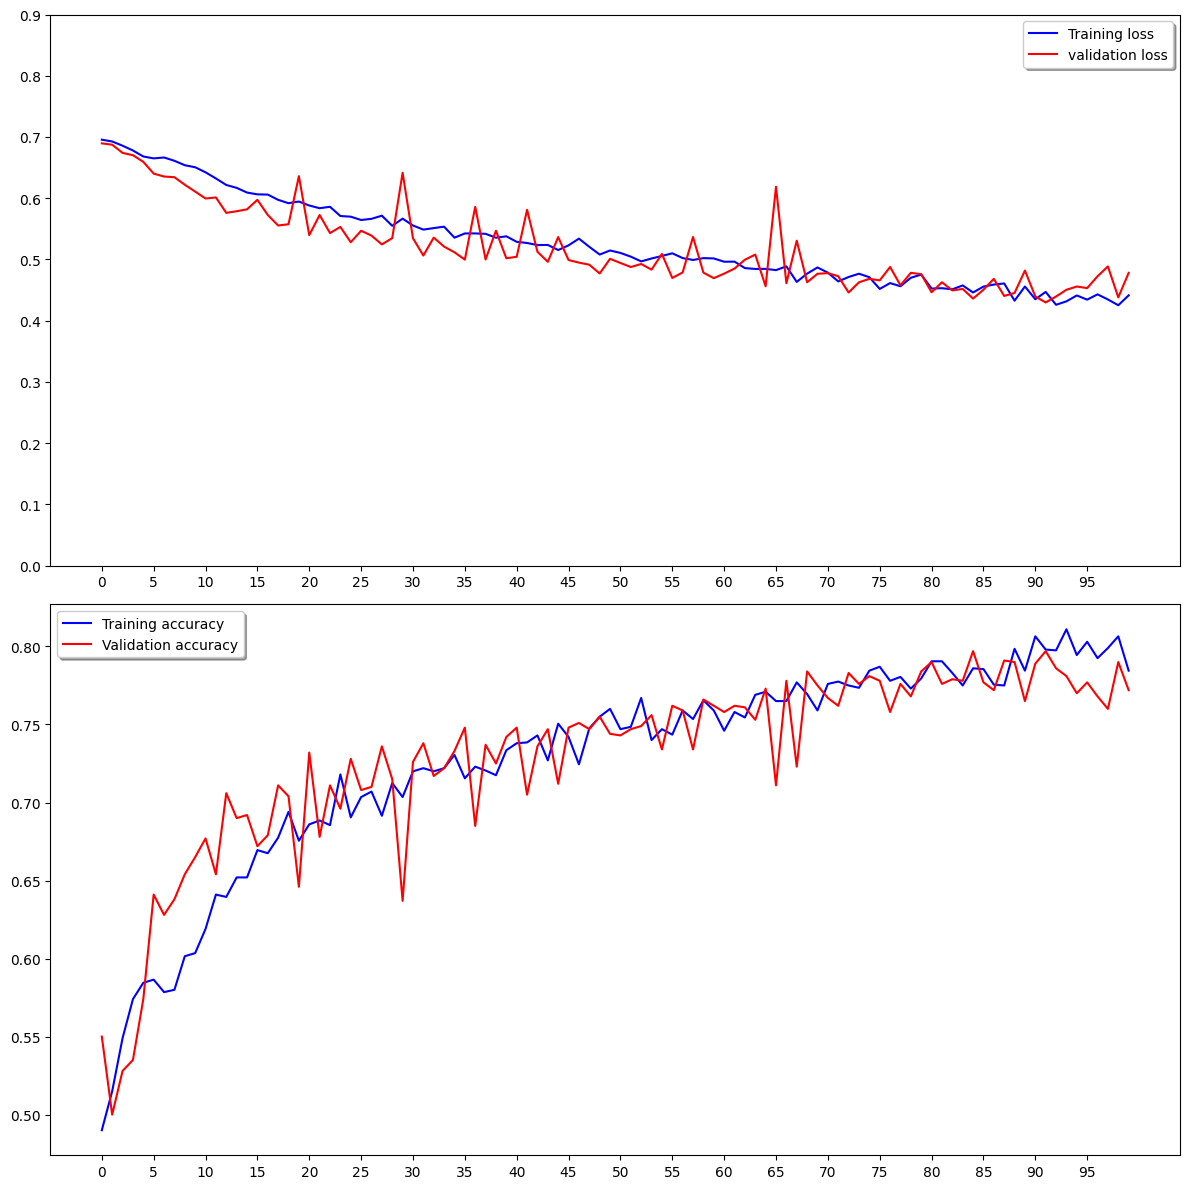

In [15]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12))
ax1.plot(hist.history['loss'], color='b', label="Training loss")
ax1.plot(hist.history['val_loss'], color='r', label="validation loss")
ax1.set_xticks(np.arange(0, 100, 5))
ax1.set_yticks(np.arange(0, 1, 0.1))
ax1.legend(loc='best', shadow=True)

ax2.plot(hist.history['acc'], color='b', label="Training accuracy")
ax2.plot(hist.history['val_acc'], color='r',label="Validation accuracy")
ax2.set_xticks(np.arange(0, 100, 5))
ax2.legend(loc='best', shadow=True)
plt.tight_layout()
plt.show()

Según vemos en la gráfica, el modelo ha ganado en precisión y además ya no se aprecia overfitting.